In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow import keras
from tensorflow.keras import layers


In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
dataset_path = '/content/drive/MyDrive/potato'


In [1]:
IMAGE_SIZE = 256
BATCH_SIZE = 32
CHANNELS = 3
EPOCHS = 50

# Load Data

In [ ]:
import shutil, os

drive_path = '/content/drive/MyDrive/potato'
local_path = '/content/potato'

# copy cleanly every time
if os.path.exists(local_path):
    shutil.rmtree(local_path)
shutil.copytree(drive_path, local_path)


dataset = tf.keras.utils.image_dataset_from_directory(
dataset_path,
    image_size=(IMAGE_SIZE,IMAGE_SIZE),
    shuffle=True,
    batch_size=BATCH_SIZE
)

Found 2152 files belonging to 3 classes.


In [ ]:
from google.colab import files
files.download("class_names.npy")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
data_cat = dataset.class_names

In [ ]:
data_cat

['Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy']

In [ ]:
len(dataset)

68

# Print Data

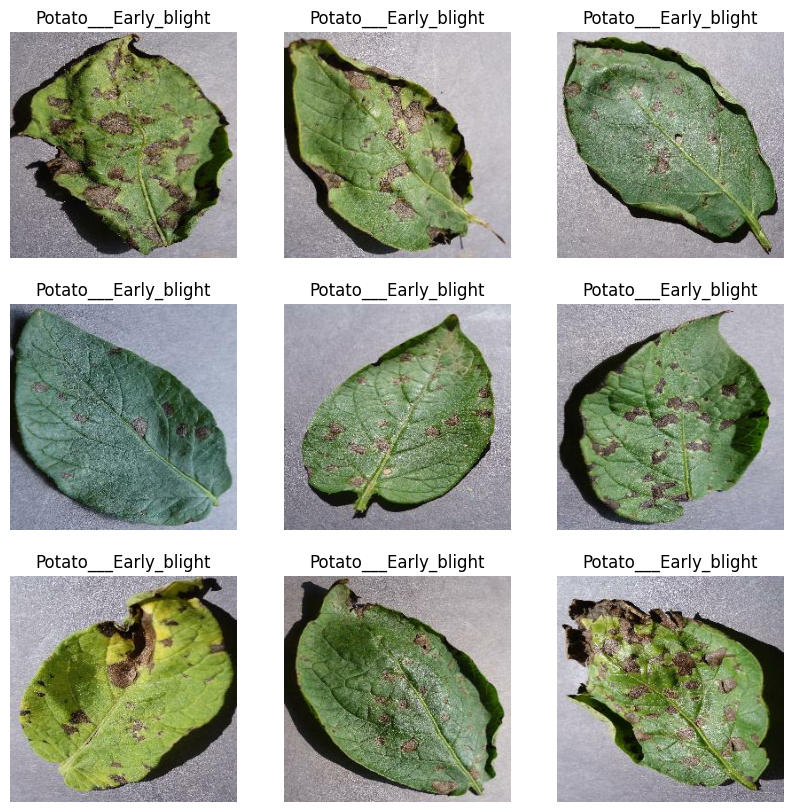

In [ ]:
plt.figure(figsize=(10,10))
for image, labels in dataset.take(1):
    for i in range(9):
        plt.subplot(3,3,i+1)
        plt.imshow(image[i].numpy().astype('uint8'))
        plt.title(data_cat[labels[i]])
        plt.axis('off')

# Split 80% Data For training 10% testing and 10% validation

In [ ]:
train_size = 0.8
len(dataset)*train_size

54.400000000000006

In [ ]:
train_ds = dataset.take(54)
len(train_ds)

54

In [ ]:
test_ds = dataset.skip(54)
len(test_ds)

14

In [ ]:
val_size = 0.1
len(dataset)*val_size

6.800000000000001

In [ ]:
val_ds = test_ds.take(6)
len(val_ds)

6

In [ ]:
test_ds = test_ds.skip(6)
len(test_ds)

8

In [ ]:
def split_dataset(data, train_split=0.8, val_split=0.1, test_split=0.1,shuffle=True, shuffle_size=10000):
    ds_size = len(data)

    if shuffle:
        data = data.shuffle(shuffle_size, seed=12)

    train_size = int(train_split * ds_size)
    val_size = int(val_split * ds_size)

    train_ds = data.take(train_size)
    val_ds = data.skip(train_size).take(val_size)
    test_ds = data.skip(train_size + val_size)

    return train_ds, val_ds, test_ds


In [ ]:
train_ds,val_ds,test_ds = split_dataset(dataset)

In [ ]:
len(train_ds)

54

In [ ]:
len(test_ds)

8

In [ ]:
train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size = tf.data.AUTOTUNE)
val_ds = val_ds.cache().shuffle(1000).prefetch(buffer_size = tf.data.AUTOTUNE)
test_ds =test_ds.cache().shuffle(1000).prefetch(buffer_size = tf.data.AUTOTUNE)

# Resize & Rescale

In [ ]:
from tensorflow.keras import layers
resize_and_rescale = tf.keras.Sequential([
    layers.Resizing(IMAGE_SIZE, IMAGE_SIZE),
    layers.Rescaling(1.0/255)
])


In [ ]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.2)
])


# Create CNN Layers

In [ ]:
from tensorflow.keras.models import Sequential
input_shape = (IMAGE_SIZE, IMAGE_SIZE,BATCH_SIZE,CHANNELS)

n_classes = 3
model =Sequential([
    data_augmentation,
    resize_and_rescale,
    layers.Conv2D(32,(3,3),activation = 'relu',input_shape = input_shape),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64,kernel_size=(3,3),activation = 'relu'),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64,kernel_size=(3,3),activation = 'relu'),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64,(3,3),activation = 'relu'),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64,(3,3),activation = 'relu'),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64,(3,3),activation = 'relu'),
    layers.MaxPooling2D((2,2)),
    layers.Flatten(),
    layers.Dense(64, activation = 'relu'),
    layers.Dense(n_classes, activation = 'softmax'),
])

model.build(input_shape=input_shape)

In [ ]:
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_1 (Sequential)       │ (256, 256, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (256, 256, 256, 3)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (256, 254, 254, 32)    │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (256, 127, 127, 32)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (256, 125, 125, 64)    │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (256, 62, 62, 64)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (256, 60, 60, 64)      │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (256, 30, 30, 64)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (256, 28, 28, 64)      │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (256, 14, 14, 64)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (256, 12, 12, 64)      │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (256, 6, 6, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (256, 4, 4, 64)        │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (256, 2, 2, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (256, 256)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (256, 64)              │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (256, 3)               │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 183,747 (717.76 KB)

 Trainable params: 183,747 (717.76 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(optimizer = 'adam',
              loss = tf.keras.losses.SparseCategoricalCrossentropy(from_logits = False),
              metrics=['accuracy'])

# Model Training 

In [ ]:
history = model.fit(
    train_ds,
    batch_size = BATCH_SIZE,
    verbose = 1,
    validation_data = val_ds,
    epochs = EPOCHS)

Epoch 1/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 24s 190ms/step - accuracy: 0.4899 - loss: 0.9329 - val_accuracy: 0.5312 - val_loss: 0.9268
Epoch 2/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 23s 59ms/step - accuracy: 0.6759 - loss: 0.7164 - val_accuracy: 0.8021 - val_loss: 0.4538
Epoch 3/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 3s 58ms/step - accuracy: 0.7766 - loss: 0.4942 - val_accuracy: 0.8750 - val_loss: 0.3032
Epoch 4/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 3s 58ms/step - accuracy: 0.8618 - loss: 0.3149 - val_accuracy: 0.9167 - val_loss: 0.2628
Epoch 5/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 3s 60ms/step - accuracy: 0.9063 - loss: 0.2502 - val_accuracy: 0.8594 - val_loss: 0.3603
Epoch 6/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 3s 59ms/step - accuracy: 0.8952 - loss: 0.2623 - val_accuracy: 0.9010 - val_loss: 0.2209
Epoch 7/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 3s 60ms/step - accuracy: 0.9193 - loss: 0.2025 - val_accuracy: 0.9427 - val_loss: 0.1447
Epoch 8/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 3s 59ms/step - accuracy: 0.9103 - loss: 0.2160 - val_accuracy: 0.9427 

In [ ]:
scores = model.evaluate(test_ds)
scores

8/8 ━━━━━━━━━━━━━━━━━━━━ 5s 21ms/step - accuracy: 0.9801 - loss: 0.0746


[0.0618833489716053, 0.98046875]

# Ploting Loss & Accuracy

In [ ]:
epochs_range = range(EPOCHS)
plt.figure(figsize=(8, 8))

# Plotting training and validation accuracy
plt.subplot(1, 2, 1)
plt.plot(epochs_range, history.history['accuracy'], label='Training Accuracy')
plt.plot(epochs_range, history.history['val_accuracy'], label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Accuracy')

# Plotting training and validation loss
plt.subplot(1, 2, 2)
plt.plot(epochs_range, history.history['loss'], label='Training Loss')
plt.plot(epochs_range, history.history['val_loss'], label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Loss')

plt.show()


# Save Model

In [ ]:
model.save('Potato_Disease_classify.keras')


In [ ]:
!zip -r potao_project.zip /content

from google.colab import files
files.download('potao_project.zip')


  adding: content/ (stored 0%)
  adding: content/.config/ (stored 0%)
  adding: content/.config/default_configs.db (deflated 98%)
  adding: content/.config/.last_opt_in_prompt.yaml (stored 0%)
  adding: content/.config/logs/ (stored 0%)
  adding: content/.config/logs/2025.07.29/ (stored 0%)
  adding: content/.config/logs/2025.07.29/13.36.15.785307.log (deflated 57%)
  adding: content/.config/logs/2025.07.29/13.36.36.776594.log (deflated 57%)
  adding: content/.config/logs/2025.07.29/13.36.37.567476.log (deflated 56%)
  adding: content/.config/logs/2025.07.29/13.36.27.119914.log (deflated 58%)
  adding: content/.config/logs/2025.07.29/13.35.49.066514.log (deflated 92%)
  adding: content/.config/logs/2025.07.29/13.36.25.001588.log (deflated 86%)
  adding: content/.config/config_sentinel (stored 0%)
  adding: content/.config/hidden_gcloud_config_universe_descriptor_data_cache_configs.db (deflated 97%)
  adding: content/.config/configurations/ (stored 0%)
  adding: content/.config/configur

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>